# 데이터 이해 및 기초 통계
- 평균, 분산, 표준편차
- 데이터 분포 시각화
- 그룹별 retention 계산

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/cookie_cats.csv')
df.sample(5)

,userid,version,sum_gamerounds,retention_1,retention_7
22559,2513129,gate_30,16,False,False
40535,4484909,gate_40,11,False,False
27840,3101778,gate_40,2,False,False
49534,5494116,gate_40,4,False,False
74080,8209235,gate_30,5,False,False


#### 변수
- userid : 유저 고유 ID
- version : 게이트 설치 위치 (gate_30/gate_40)
- sum_gamerounds : 설치 후 14일 동안 플레이어가 플레이 한 라운드 수
- retention_1 : 설치 후 1일째에 다시 게임을 플레이 했는지 여부
- retention_7 : 설치 후 7일째에 다시 게임을 플레이 했는지 여부


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [15]:
print("userid unique counts: ", df.userid.nunique())

userid unique counts:  90189


In [70]:
df.version.value_counts('False')

version
gate_40    0.504374
gate_30    0.495626
Name: proportion, dtype: float64

# 데이터 EDA
- 평균, 분산, 표준편차

In [ ]:
# 14일 간 플레이 한 스테이지
df_stats = df.groupby('version').sum_gamerounds.describe()
df_stats

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44700.0,52.456264,256.716423,0.0,5.0,17.0,50.0,49854.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


변동계수 CV(coefficient of variation) = std / mean

In [ ]:
df_stats['cv'] = df_stats['std'] / df_stats['mean']
df_stats

,count,mean,std,min,25%,50%,75%,max,cv
version,,,,,,,,,
gate_30,44700.0,52.456264,256.716423,0.0,5.0,17.0,50.0,49854.0,4.893914
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0,2.013584


In [51]:
df.sort_values('sum_gamerounds', ascending=False)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
...,...,...,...,...,...
86102,9536993,gate_40,0,False,False
86092,9535396,gate_40,0,False,False
3050,336781,gate_30,0,False,False
86120,9539016,gate_30,0,False,False


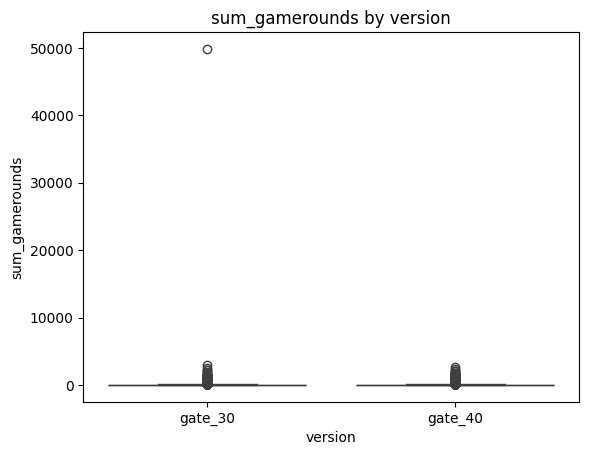

In [ ]:
sns.boxplot(x='version', y='sum_gamerounds', data=df)

plt.title('sum_gamerounds by version')
plt.show()

In [ ]:
# 이상치 제거 df_filtered

def remove_outliers(group):
    Q1 = group['sum_gamerounds'].quantile(0.25)
    Q3 = group['sum_gamerounds'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['sum_gamerounds'] >= lower) & (group['sum_gamerounds'] <= upper)]

df_filtered = df.groupby('version', group_keys=False).apply(remove_outliers)

C:\Users\wjswl\AppData\Local\Temp\ipykernel_33692\1444608270.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df.groupby('version', group_keys=False).apply(remove_outliers)


In [43]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79964 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          79964 non-null  int64 
 1   version         79964 non-null  object
 2   sum_gamerounds  79964 non-null  int64 
 3   retention_1     79964 non-null  bool  
 4   retention_7     79964 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.6+ MB


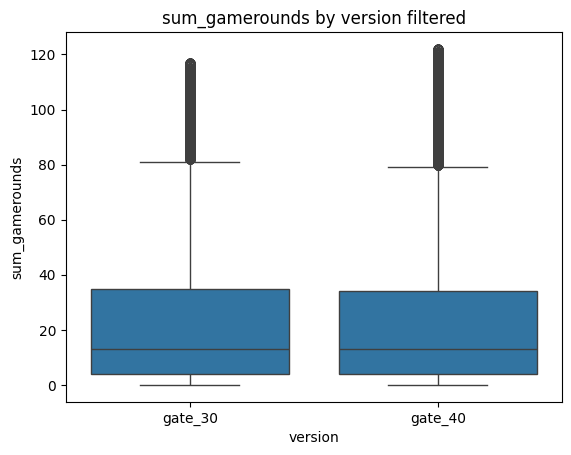

In [42]:
sns.boxplot(x='version', y='sum_gamerounds', data=df_filtered)

plt.title('sum_gamerounds by version filtered')
plt.show()

- gate_30 그룹의 유저 중 한 명이 sum_gamerounds 수치가 극단적으로 큰 경우(고래 유저)가 있음
- 일반 유저 분석을 할 경우 고래 유저의 데이터를 제외 하고 분석 (고래 유저 데이터만 따로 분석)
- 전체 매출/성과를 봐야 할 경우 모두 포함해야 함
- 14일 동안의 게임 플레이니, 하루 평균 플레이 스테이지 기준 라이트/일반/헤비로 그룹을 나누는 것도 좋아 보임

현재 유저의 성향(일반/헤비) 비율에 따라서 더 확보 혹은 개선해야 하는 비율의 유저의 성향에 맞춰 gate 설정하는 것은 어떨까?

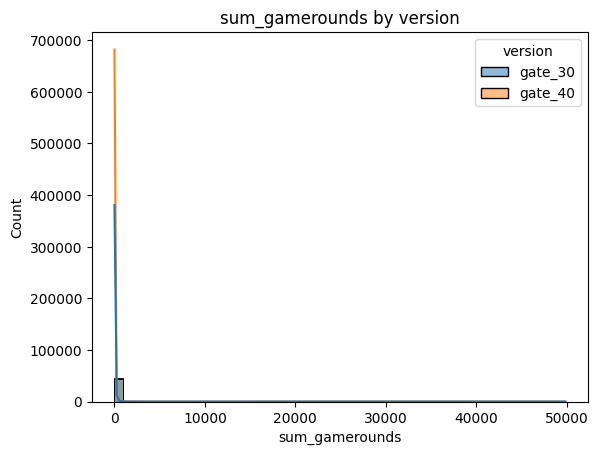

In [ ]:
# 이상치 포함 플레이 스테이지 수 히스토그램
sns.histplot(data=df, x='sum_gamerounds', hue='version', bins=50, kde=True)

plt.title('sum_gamerounds by version')
plt.show()

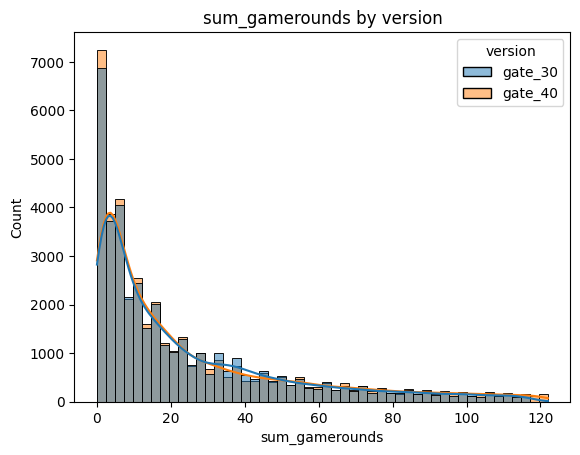

In [ ]:
# 히스토그램 비교 : 두 그룹의 일반 유저의 플레이 스테이지 수가 비슷한 분포를 보임. (이상치 제외)

sns.histplot(data=df_filtered, x='sum_gamerounds', hue='version', bins=50, kde=True)

plt.title('sum_gamerounds by version')
plt.show()

## gate_30 그룹의 retention

In [ ]:
df_30 = df[df.version == 'gate_30'].copy()
df_30.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44700 entries, 0 to 90186
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          44700 non-null  int64 
 1   version         44700 non-null  object
 2   sum_gamerounds  44700 non-null  int64 
 3   retention_1     44700 non-null  bool  
 4   retention_7     44700 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 1.4+ MB


In [ ]:
# retention 계산

def print_group_retention(df=df, group='group'):
    print(group + ' retention_1 :', df.retention_1.mean() * 100, '%')
    print(group + ' retention_7 :', df.retention_7.mean() * 100, '%')
    print(group + ' core :', ((df.retention_1) & (df.retention_7)).mean() * 100, '%')

In [83]:
print_group_retention(df=df_30, group='gate_30')

gate_30 retention_1 : 44.81879194630872 %
gate_30 retention_7 : 19.020134228187917 %
gate_30 core : 14.935123042505595 %


# gate_40 그룹 retention

In [86]:
df_40 = df[df.version == 'gate_40'].copy()
df_40.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45489 entries, 2 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          45489 non-null  int64 
 1   version         45489 non-null  object
 2   sum_gamerounds  45489 non-null  int64 
 3   retention_1     45489 non-null  bool  
 4   retention_7     45489 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 1.5+ MB


In [87]:
print_group_retention(df=df_40, group='gate_40')

gate_40 retention_1 : 44.22827496757458 %
gate_40 retention_7 : 18.200004396667328 %
gate_40 core : 14.302358812020488 %
